<a href="https://colab.research.google.com/github/Sr-santi/seq2seq_electric_curves_reconstruction/blob/master/customer_electricity_consumption_challenge.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

# Seq2Seq Challenge

Given the challenge inside [Challenge Data](https://challengedata.ens.fr/challenges/160), we will have a set of synthetic data that represents the consumption of multiple users, where 1000 of these consumption curves contain random data removal, The goal of that challenge is to propose replacements for missing values (“fill the holes”) in the 1000 curves.

Steps to consider:
1. We are going to read the data and separate the holed curves
2. We are going to train our model with the curves that are complete and train and evaluate the model with these data
3. later we will test the results with the testing data and if everything looks good, we are going to propose the values for the holed curves
4. We can consider some metrics to check how accurate is our model and the predictions


# Preparing and understanding my dataset

TODOs:

1. Organize the data analysis sections to show a clear process of why we are normalizing the data , how is our data distribution and make it clear the go throught of the data that we are using
2. Make each section interconnected to show a clear understanding of the step by step process here

## Data Loading

In [1]:
# reading data

import torch
import torch.nn as nn
import numpy as np
import pandas as pd
import time
import math
import matplotlib.pyplot as plt
import os

# --- Environment Detection & Setup ---
try:
    # This will succeed only in Colab
    from google.colab import drive
    print("Running in Google Colab. Mounting Drive...")
    drive.mount('/content/drive')
    
    # Set the Colab data path
    DATA_DIR = "/content/drive/MyDrive/energy_consumption_challenge/"
    SAVE_DIR = "/content/drive/MyDrive/energy_consumption_challenge/"
    
except ImportError:
    # This block executes if you are running locally
    print("Running locally. Using local data directory...")
    
    # Set the local data path (e.g., the 'data' folder we discussed earlier)
    DATA_DIR = "./data/"
    SAVE_DIR = "./checkpoints/"
    
    # Make sure the local save directory exists
    os.makedirs(SAVE_DIR, exist_ok=True)

Running locally. Using local data directory...


In [2]:
# How many cores are available?
os.cpu_count()

12

In [3]:
import pandas as pd

# Load the data
x_test_data = pd.read_csv(f"{DATA_DIR}/X_test_XKVc4no.csv", index_col=0, parse_dates=True)
y_train_data = pd.read_csv(f"{DATA_DIR}/y_train_u0UkKEh.csv", index_col=0, parse_dates=True)
x_train_data = pd.read_csv(f"{DATA_DIR}/X_train_78VdSWL.csv", index_col=0, parse_dates=True)

In [4]:
from sklearn.model_selection import train_test_split

def analyze_cols(df):
    cols = df.columns.tolist()
    holed = [c for c in cols if 'holed' in c.lower()]
    # Since index_col=0 was used, all current columns are either 'holed' or 'normal'
    normal = [c for c in cols if 'holed' not in c.lower()]
    return len(holed), len(normal), holed, normal

# Get stats using the full DataFrames
h_xtrain, n_xtrain, x_train_holed_cols, x_train_normal_cols  = analyze_cols(x_train_data)
h_xtest, n_xtest, x_test_holed_cols, x_test_normal_cols = analyze_cols(x_test_data)
# y_train_data contains the answers for the x_train_data dataset
h_ytrain, n_ytrain = (0, y_train_data.shape[1])


# Create the actual DataFrames
# the holed columns are the same inside train and test in this case
# we have some redundancy in the data
df_train_holed = x_train_data[x_train_holed_cols]
df_train_normal = x_train_data[x_train_normal_cols]

# df_test_holed = x_test_data[x_test_holed_cols]
df_test_normal = x_test_data[x_test_normal_cols]

# combined dataset
df_normal_all = pd.concat([df_train_normal, df_test_normal], axis=1)

# Split into Train (80%) and Validation (20%)
# We split by column (Meter ID) so the model learns from different buildings
train_ids, val_ids = train_test_split(df_normal_all.columns, test_size=0.2, random_state=42)

# probably remove next lines until summary
df_train_pool = df_normal_all[train_ids]
# df_val_pool = df_normal_all[val_ids]

# Calculate the Grid Pulse (ONLY from training pool to avoid leakage)
grid_pulse = pd.DataFrame(index=df_train_pool.index)
grid_pulse['grid_mean'] = df_train_pool.mean(axis=1)
grid_pulse['grid_std'] = df_train_pool.std(axis=1)
# -----------------------------------------



# Build the Summary Structure
summary_df = pd.DataFrame({
    "Total Rows": [x_train_data.shape[0], y_train_data.shape[0], x_test_data.shape[0]],
    "Total Columns": [x_train_data.shape[1], y_train_data.shape[1], x_test_data.shape[1]],
    "Holed Columns": [h_xtrain, h_ytrain, h_xtest],
    "Normal Columns": [n_xtrain, n_ytrain, n_xtest]
}, index=["X_train", "y_train", "X_test"])

print("--- Dataset Column Summary ---")
print(summary_df)

--- Dataset Column Summary ---
         Total Rows  Total Columns  Holed Columns  Normal Columns
X_train        1057          21000           1000           20000
y_train        1057           1000              0            1000
X_test         1057          38140           1000           37140


In [5]:
print(f"Train Date Range: {df_train_holed.index.min()} to {df_train_holed.index.max()}")
# we have data from 01-09 to 01-31
# We can divide the data in smaller time windows and ranges to manage it better and train de model
# Sampling is every 30 min

Train Date Range: 2023-01-09 00:00:00 to 2023-01-31 00:00:00


## Holed curves considerations

For the 1000 curves that we need to fix, we want to know how our data is composed by trying to understand what is behavior or the data that is not registered in order to determinate what is the best strategy for the model training setup and data reconstruction.

1. First we are going to check an overall picture of the missing data to later make an analysis of the missing data composition
2. For the analisys; We want to know how long are the consecutive missing points, the distribution of the missing points and how they are distributed along the consumption curves
3. After consider the previous information we will conclude some consideration and details to consider during our training step

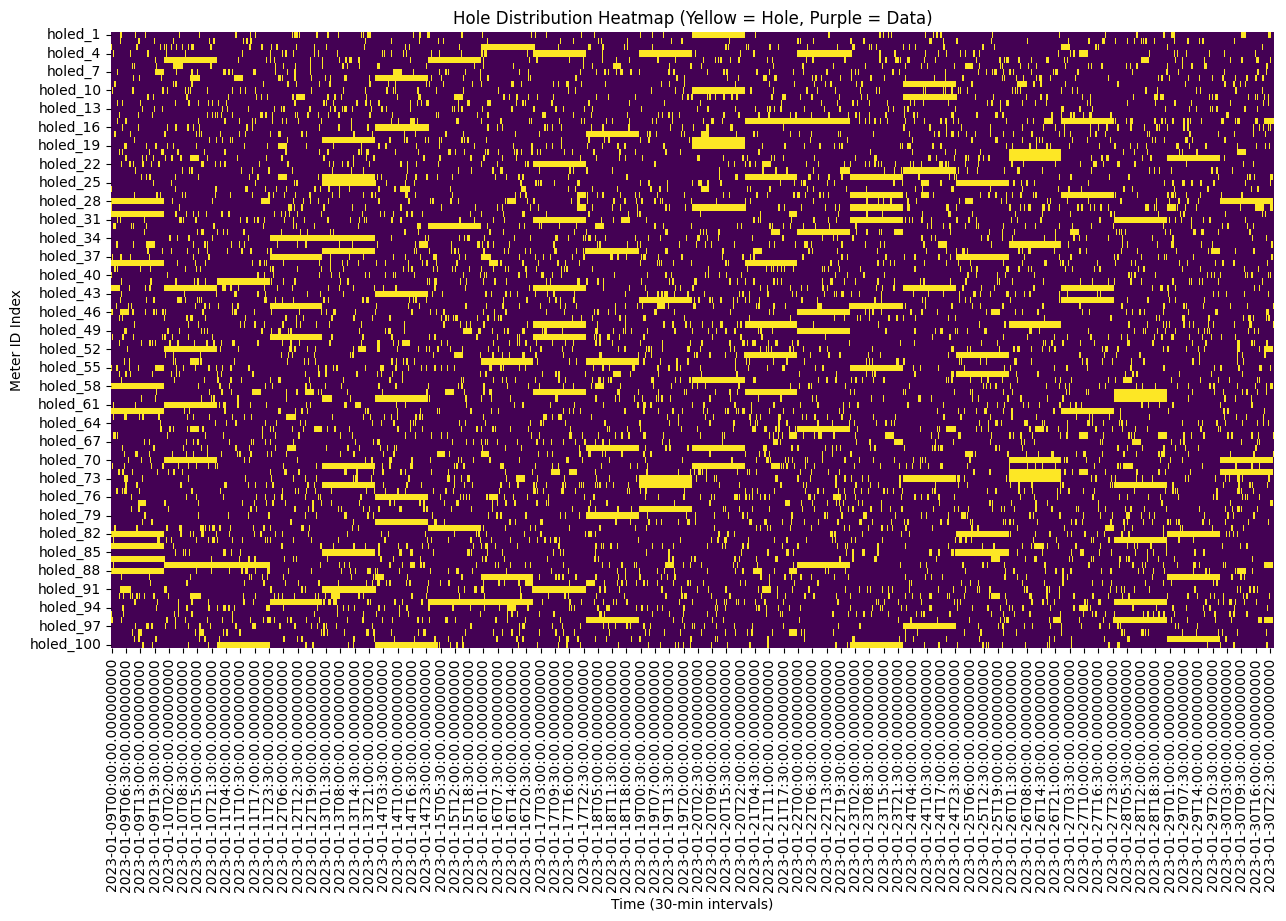

In [ ]:
# Overall picture of the missing data using a heat map
import matplotlib.pyplot as plt
import seaborn as sns

def analyze_hole_distribution(df_holed):
    """
    df_holed: The 1,000 meters with gaps.
    Identifies where zeros/NaNs are located across the month.
    """
    # Create a binary mask of where the 'holes' are (0 or NaN)
    # Adjust the condition if you think some 0s are valid consumption
    # hole_mask = (df_holed == 0) | (df_holed.isna())
    hole_mask = (df_holed.isna())

    plt.figure(figsize=(15, 8))
    # Plotting a subset (e.g., first 100 meters) to see the temporal distribution
    sns.heatmap(hole_mask.iloc[:, :100].T, cbar=False, cmap='viridis')
    plt.title("Hole Distribution Heatmap (Yellow = Hole, Purple = Data)")
    plt.xlabel("Time (30-min intervals)")
    plt.ylabel("Meter ID Index")
    plt.show()

    # Calculate gap lengths
    gap_lengths = hole_mask.astype(int).cumsum()
    # (Optional: Add logic here to histogram the lengths of consecutive zeros)

analyze_hole_distribution(df_train_holed)

--- Verification for holed_4 ---
Number of holes found in X_train: 207

y_train distribution for holed_4:
count    1057.000000
mean      131.353832
std       235.907929
min         0.000000
25%         0.000000
50%         1.000000
75%       210.000000
max      1646.000000
Name: holed_4, dtype: float64
Max consecutive missing points: 180
Average gap length: 13.17 



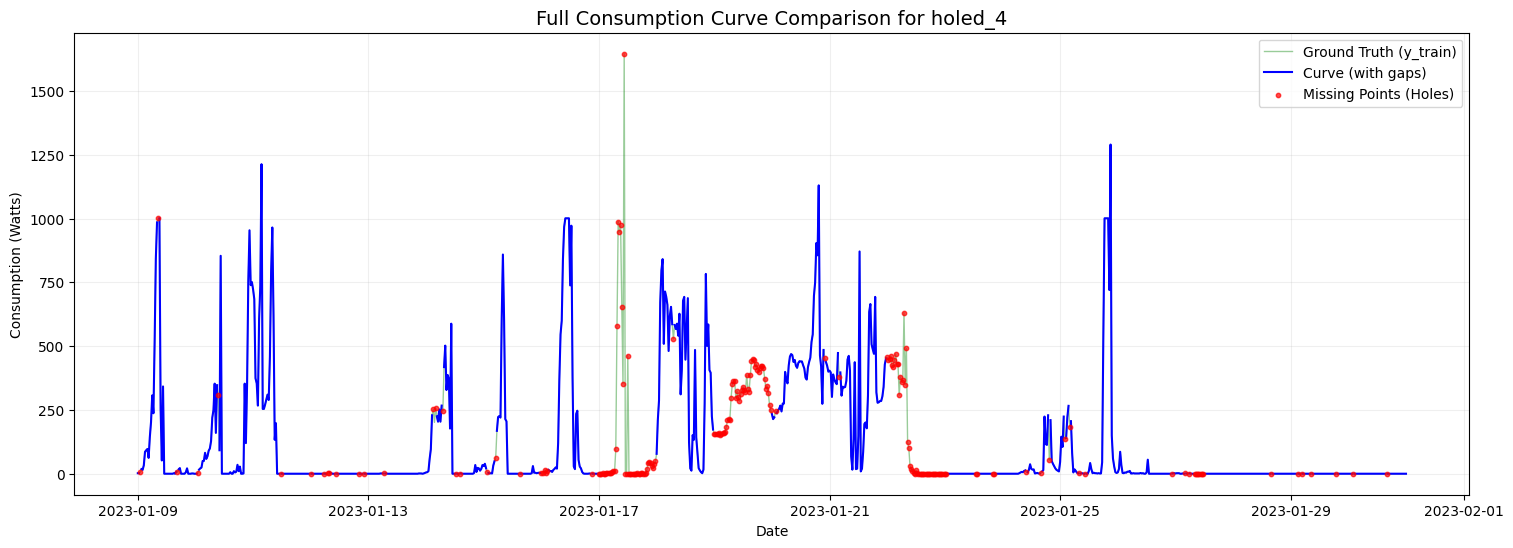

In [ ]:
# Here we are seeing the curve that we need to reconstruct compared with
# the curve that contains all the missing points
# This is an specific example to vizualize the problem
import numpy as np
import matplotlib.pyplot as plt

CURVE_INDEX = 3
# Let's check the first holed column
sample_col = x_train_holed_cols[CURVE_INDEX]

# Strategy: Find where X_train is NaN (where the data is removed), and see what y_train has there
# (Assuming holes are represented by NaN)
holes_mask = df_train_holed[sample_col].isna()

print(f"--- Verification for {sample_col} ---")
print(f"Number of holes found in X_train: {holes_mask.sum()}")

# Check distribution of values in y_train for that column
print(f"\ny_train distribution for {sample_col}:")
print(y_train_data[sample_col].describe())

# -------------------------------------------------------
# This tells us if holes are isolated or in big chunks
is_hole = (df_train_holed[sample_col] == 0) | (df_train_holed[sample_col].isna())
gap_lengths = is_hole.groupby((is_hole != is_hole.shift()).cumsum()).sum()
print(f"Max consecutive missing points: {gap_lengths.max()}")
print(f"Average gap length: {gap_lengths[gap_lengths > 0].mean():.2f} \n")

# -------------------------------------------------------
# 1. Plotting the WHOLE curve
plt.figure(figsize=(18, 6))

# Plot ground truth
plt.plot(y_train_data.index, y_train_data[sample_col], label='Ground Truth (y_train)', color='green', alpha=0.4, linewidth=1)

# Plot the data with holes (X_train) - we filter out the 0s to show the gaps
visible_data = df_train_holed[sample_col]
plt.plot(visible_data.index, visible_data, label='Curve (with gaps)', color='blue', linewidth=1.5)

# Highlight where the holes were (NaN values)
is_hole = df_train_holed[sample_col].isna()
plt.scatter(df_train_holed.index[is_hole], y_train_data[sample_col][is_hole],
            color='red', s=10, label='Missing Points (Holes)', alpha=0.7, zorder=5)

plt.title(f"Full Consumption Curve Comparison for {sample_col}", fontsize=14)
plt.xlabel("Date")
plt.ylabel("Consumption (Watts)")
plt.legend()
plt.grid(True, alpha=0.2)
plt.show()

## Holed curves analysis

hole distribution analysis on the 1,000 holed consumption curves in `df_train_holed`.

Specifically:
1.  **Calculate Gap Metrics**: Identify sequences of missing data (NaNs) and calculate the length of every consecutive gap for all 1,000 meters.
2.  **Aggregate Statistics**: Compute global metrics including the mean gap length, median gap length, and the distribution of maximum gap sizes across all users.
3.  **Visualize Gap Distribution**: histogram howing the distribution of these gap lengths to determine if holes are typically short bursts or long-term outages.
4.  **Summary and Implications**: Summary of the findings and how these gap characteristics (e.g., long vs. short sequences) influence the Seq2Seq architecture or window size selection for the "fill the holes" problem.

The conclutions of this analysis:

**Gap Frequency and Scale**: A total of 55,966 gaps were identified across 1,000 meters. The distribution is heavily skewed toward very short sequences, with a global median and mode of 1.0 interval.

**Long-Term Outages**: Although long outages are rare (only 0.34% of gaps exceed 24 hours), they are significant. The 99th percentile of gap lengths is 48 intervals (24 hours), and the maximum recorded gap is 857 intervals (~18 days).

**Per-Meter Extremes**: On average, the maximum gap a single meter experiences is 38.29 intervals. At least 50% of the meters have encountered a gap of at least 24 hours (48 intervals).


Considerations for our setup:

These results indicates that while most gaps are single intervals, the 99th percentile reaches 48 intervals (24 hours). Consequently, a context window of at least 168 intervals (7 days) is recommended to capture weekly seasonality. The architecture should be an Encoder-Decoder (Seq2Seq) model that incorporates the grid_mean (Global Grid Pulse) as an external feature to provide a baseline for long-term outages (up to 857 intervals).

### Calculate Gap Metrics

calculate the gap lengths for all 1,000 holed meters by iterating through the columns of df_train_holed, identifying consecutive NaNs, and storing both individual gap lengths and the maximum gap per meter.

In [ ]:
all_gap_lengths = []
max_gaps_per_meter = {}

# Iterate through each holed meter (1000 columns)
for col in df_train_holed.columns:
    # Identify NaNs
    is_na = df_train_holed[col].isna()

    # Group consecutive NaNs and count their lengths
    # (is_na != is_na.shift()).cumsum() creates a new group ID every time the value changes from NaN to non-NaN or vice-versa
    gap_groups = is_na.groupby((is_na != is_na.shift()).cumsum())

    # Filter only groups that are NaNs and get their lengths
    # We use .sum() because 'is_na' is boolean (True=1, False=0)
    lengths = gap_groups.sum()
    lengths = lengths[lengths > 0].tolist()

    all_gap_lengths.extend(lengths)
    max_gaps_per_meter[col] = max(lengths) if lengths else 0

# Verification
num_meters_processed = len(max_gaps_per_meter)
print(f"Total meters processed: {num_meters_processed}")
print(f"Total number of gaps identified across all meters: {len(all_gap_lengths)}")
if len(all_gap_lengths) > 0:
    print(f"Global Maximum Gap Length: {max(all_gap_lengths)}")
    print(f"Global Average Gap Length: {np.mean(all_gap_lengths):.2f}")

# Store results for later use
global_gap_series = pd.Series(all_gap_lengths)

Total meters processed: 1000
Total number of gaps identified across all meters: 55966
Global Maximum Gap Length: 857
Global Average Gap Length: 2.32


### Aggregate Statistics

global and per-meter gap statistics, including percentiles and descriptive summaries, using the previously defined `global_gap_series` and `max_gaps_per_meter` to quantify the nature of missing data.


In [ ]:
import pandas as pd
import numpy as np

# 1. Global Gap Statistics
global_mean = global_gap_series.mean()
global_median = global_gap_series.median()
global_mode = global_gap_series.mode()[0]

# 2. Tail Distribution (Percentiles)
percentiles = [0.25, 0.75, 0.90, 0.95, 0.99]
gap_percentiles = global_gap_series.quantile(percentiles)

# 3. Per-Meter Max Gap Analysis
max_gaps_series = pd.Series(list(max_gaps_per_meter.values()))
max_gap_stats = max_gaps_series.describe(percentiles=[0.5, 0.75, 0.9])

# 4. Display Results
print("--- Global Gap Length Statistics ---")
print(f"Mean Gap Length:   {global_mean:.2f} (intervals)")
print(f"Median Gap Length: {global_median:.2f}")
print(f"Mode Gap Length:   {global_mode}")

print("\n--- Global Gap Percentiles ---")
for p, val in gap_percentiles.items():
    print(f"{int(p*100)}th Percentile: {val:.1f} intervals")

print("\n--- Statistics of Maximum Gaps per Meter ---")
print(max_gap_stats)

# Logic check for Seq2Seq
long_gaps_count = (global_gap_series > 48).sum()
print(f"\nTotal gaps longer than 24 hours (48 intervals): {long_gaps_count}")
print(f"Percentage of gaps that are long-term outages (24 hours): {(long_gaps_count/len(global_gap_series))*100:.2f}%")

--- Global Gap Length Statistics ---
Mean Gap Length:   2.32 (intervals)
Median Gap Length: 1.00
Mode Gap Length:   1

--- Global Gap Percentiles ---
25th Percentile: 1.0 intervals
75th Percentile: 1.0 intervals
90th Percentile: 2.0 intervals
95th Percentile: 3.0 intervals
99th Percentile: 48.0 intervals

--- Statistics of Maximum Gaps per Meter ---
count    1000.00000
mean       38.28600
std        34.82877
min         2.00000
50%        48.00000
75%        48.00000
90%        50.00000
max       857.00000
dtype: float64

Total gaps longer than 24 hours (48 intervals): 191
Percentage of gaps that are long-term outages (24 hours): 0.34%


### Visualize Gap Distribution


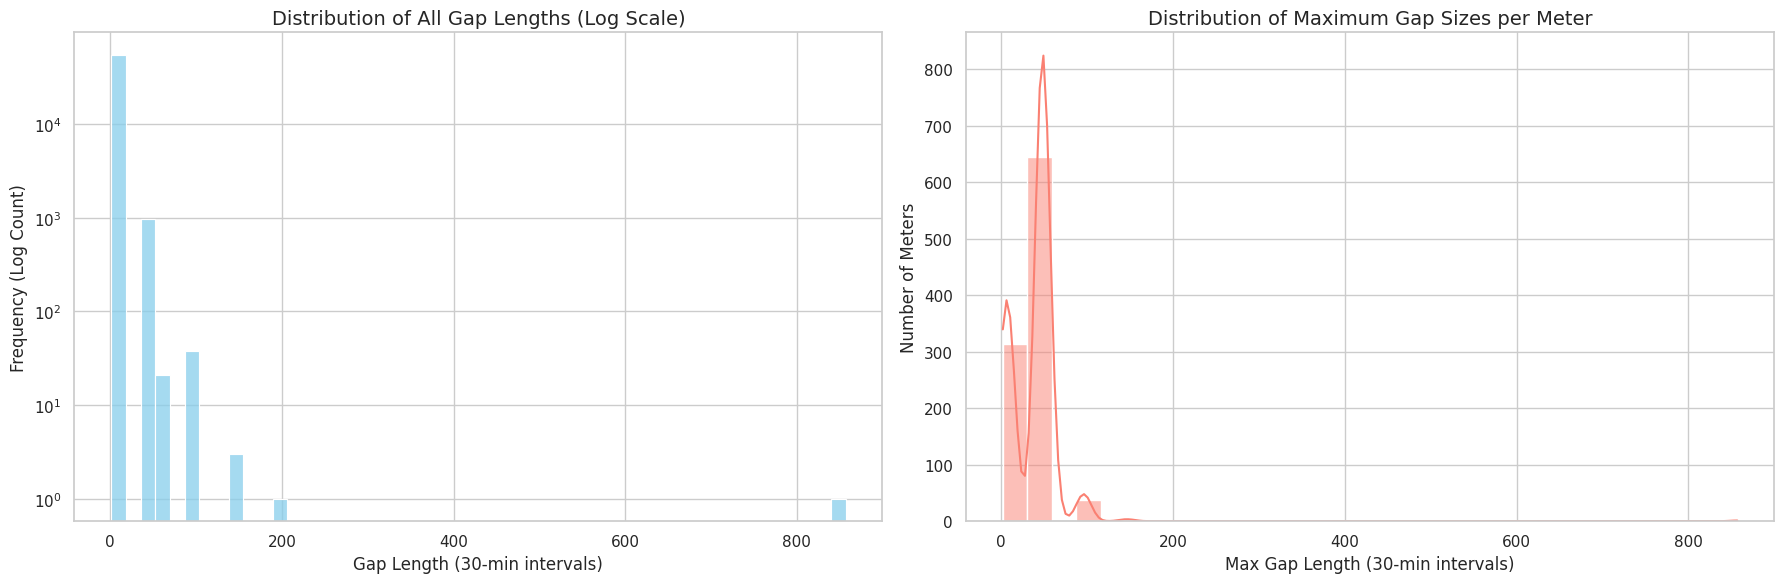

In [ ]:
import matplotlib.pyplot as plt
import seaborn as sns

# Set the aesthetic style for the plots
sns.set_theme(style="whitegrid")

# Create a figure with two subplots
fig, (ax1, ax2) = plt.subplots(1, 2, figsize=(18, 6))

# 1. Distribution of All Gap Lengths (Global)
sns.histplot(global_gap_series, bins=50, kde=False, color='skyblue', ax=ax1)
ax1.set_yscale('log')
ax1.set_title("Distribution of All Gap Lengths (Log Scale)", fontsize=14)
ax1.set_xlabel("Gap Length (30-min intervals)", fontsize=12)
ax1.set_ylabel("Frequency (Log Count)", fontsize=12)

# 2. Distribution of Maximum Gaps per Meter
sns.histplot(max_gaps_series, bins=30, kde=True, color='salmon', ax=ax2)
ax2.set_title("Distribution of Maximum Gap Sizes per Meter", fontsize=14)
ax2.set_xlabel("Max Gap Length (30-min intervals)", fontsize=12)
ax2.set_ylabel("Number of Meters", fontsize=12)

plt.tight_layout()
plt.show()

-----------------------------------------

## Data analysis

We will analyze our training data to know how is the distribution of the consumption along the training data


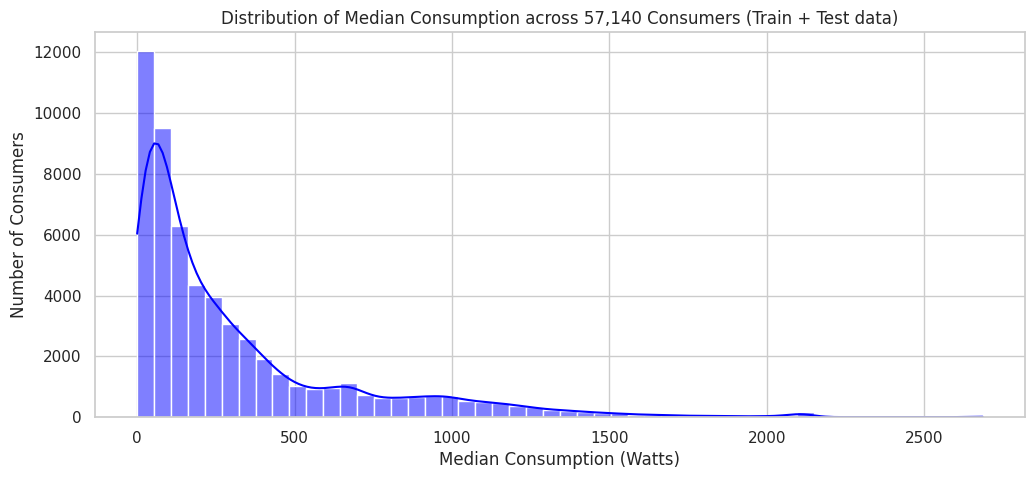

Lowest Median: 0.00
Highest Median: 2685.00
Average of Medians: 314.04


In [ ]:
import matplotlib.pyplot as plt
import seaborn as sns

# 1. Calculate Median Consumption for each of the consumers in train data
train_data_medians = df_normal_all.median(axis=0)

# 2. Plot the distribution of these medians
plt.figure(figsize=(12, 5))
sns.histplot(train_data_medians, bins=50, kde=True, color='blue')
plt.title("Distribution of Median Consumption across 57,140 Consumers (Train + Test data)")
plt.xlabel("Median Consumption (Watts)")
plt.ylabel("Number of Consumers")
plt.show()

print(f"Lowest Median: {train_data_medians.min():.2f}")
print(f"Highest Median: {train_data_medians.max():.2f}")
print(f"Average of Medians: {train_data_medians.mean():.2f}")

In [ ]:
import matplotlib.pyplot as plt
import seaborn as sns

quantiles_to_check = [0.05, 0.25, 0.50, 0.75, 0.95, 0.99]

# 1. Global Quantiles (All data points in the DataFrame combined)
global_quantiles = df_normal_all.stack().quantile(quantiles_to_check)

# 2. Quantiles per consumer (Summary of how quantiles vary across the 20,000 columns)
col_quantiles = df_normal_all.quantile(quantiles_to_check)

print("--- Global Quantiles (Entire Dataset) ---")
display(global_quantiles.to_frame(name='Watts'))

--- Global Quantiles (Entire Dataset) ---


,Watts
0.05,0.0
0.25,59.0
0.50,174.0
0.75,442.0
0.95,1276.0
0.99,2101.0


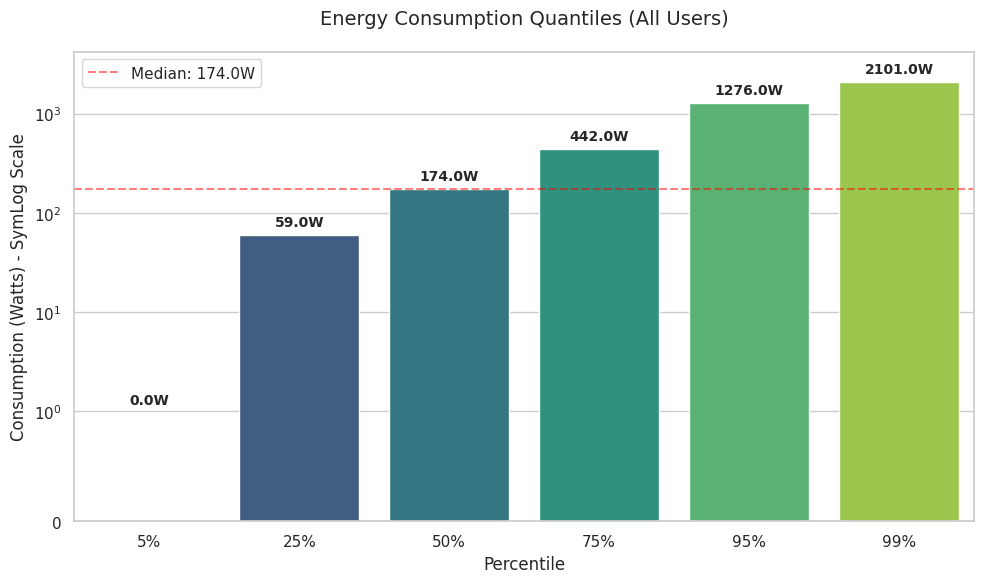

In [ ]:
import matplotlib.pyplot as plt
import seaborn as sns

# 1. Prepare data with string labels
plot_data = global_quantiles.copy()
plot_data.index = [f"{int(i*100)}%" for i in plot_data.index]

plt.figure(figsize=(10, 6))
sns.set_style("whitegrid")

# 2. Fix the warning: Assign hue=x and legend=False
ax = sns.barplot(
    x=plot_data.index,
    y=plot_data.values,
    hue=plot_data.index,
    palette='viridis',
    legend=False
)

# 3. Use 'symlog' to handle the 0.0W value while emphasizing scale
# linthresh=1 ensures the log behavior starts very early
ax.set_yscale("symlog", linthresh=1)

plt.title("Energy Consumption Quantiles (All Users)", fontsize=14, pad=20)
plt.ylabel("Consumption (Watts) - SymLog Scale", fontsize=12)
plt.xlabel("Percentile", fontsize=12)

# Reference line for the Median
median_val = global_quantiles.loc[0.50]
plt.axhline(median_val, color='red', linestyle='--', alpha=0.5, label=f'Median: {median_val:.1f}W')

# 4. Clean annotations
for i, v in enumerate(plot_data.values):
    plt.text(i, v * 1.15 if v > 0 else 1.1, f'{v:.1f}W',
             ha='center', va='bottom', fontsize=10, fontweight='bold')

plt.ylim(0, global_quantiles.max() * 2) # Give some head room for text
plt.legend()
plt.tight_layout()
plt.show()

In [ ]:
from scipy.stats import skew, kurtosis

def calculate_distribution_stats(series, name):
    stats = {
        'Metric': [
            'Mean', 'Median', 'Standard Deviation',
            'Median Absolute Deviation (MAD)', 'Variance',
            'Skewness', 'Kurtosis', 'Min', 'Max'
        ],
        'Value': [
            series.mean(),
            series.median(),
            series.std(),
            (series - series.median()).abs().median(),
            series.var(),
            skew(series.dropna()),
            kurtosis(series.dropna()),
            series.min(),
            series.max()
        ]
    }
    return pd.DataFrame(stats).set_index('Metric')

# Let's analyze the distribution of the average grid consumption
grid_stats = calculate_distribution_stats(train_data_medians, 'Grid Mean Distribution')
print("--- Statistical Summary of Train Grid Mean ---")
display(grid_stats)

--- Statistical Summary of Train Grid Mean ---


,Value
Metric,
Mean,314.038152
Median,169.000000
Standard Deviation,375.408388
Median Absolute Deviation (MAD),128.000000
Variance,140931.457688
Skewness,2.027045
Kurtosis,4.746335
Min,0.000000
Max,2685.000000


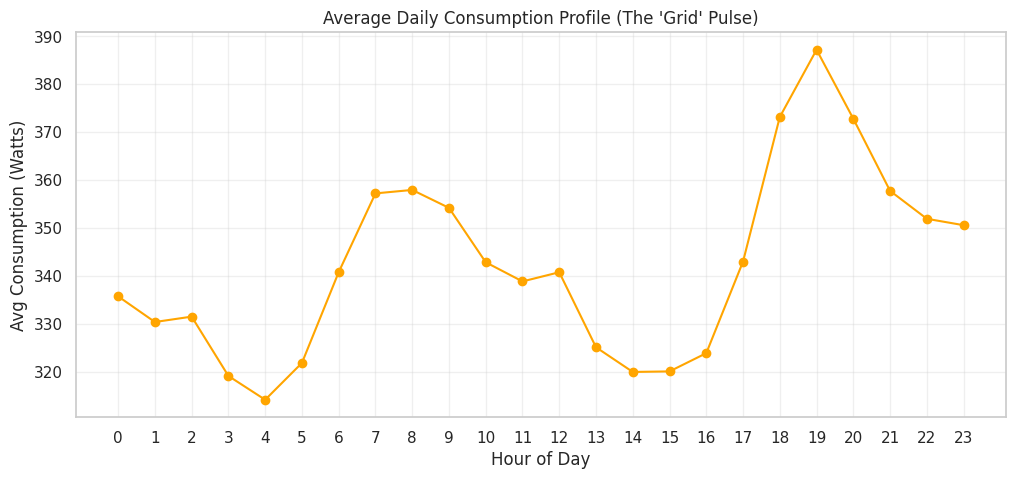

In [ ]:
# 1. Create a "Global Grid" feature by averaging all normal columns
grid_mean = df_normal_all.mean(axis=1)

# 2. Analyze Seasonality (Average Day)
# We group by the hour of the index
daily_profile = grid_mean.groupby(grid_mean.index.hour).mean()

plt.figure(figsize=(12, 5))
daily_profile.plot(kind='line', marker='o', color='orange')
# daily_profile_test.plot(kind='line', marker='o', color='blue')
plt.title("Average Daily Consumption Profile (The 'Grid' Pulse)")
plt.xlabel("Hour of Day")
plt.ylabel("Avg Consumption (Watts)")
plt.xticks(range(0, 24))
plt.grid(True, alpha=0.3)
plt.show()

Text(0, 0.5, 'magnitude')

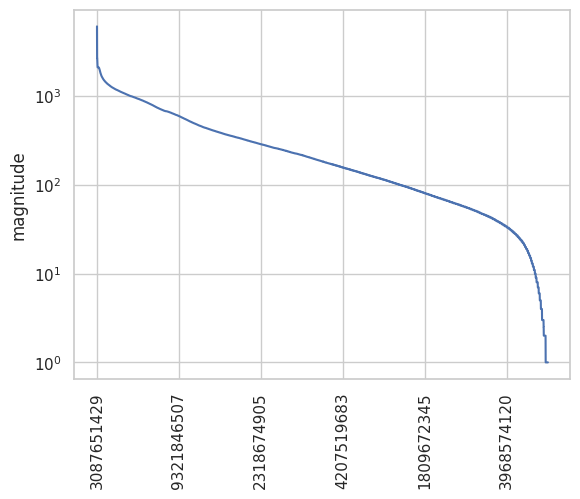

In [ ]:
df_normal_all[df_normal_all!=0].median().sort_values(ascending=False).plot(rot=90)
plt.yscale("log")

plt.ylabel("magnitude")

# Text to consider:
# we have three orders of magnitude (from $10^0$ to $10^3$) confirms that a "one size fits all" model will struggle.
# data is "top-heavy."

## Data Normalization and DataSet classes

Based on the previous analysis, We should apply Individual Standard Scaling (Or robust scaling) before the creation of the time windows, additional to that the analysis of the missing data suggest us that we should defined a window size of 336 observations (around 7 days)

Normalization:

$$z_i = \frac{x_i - \mu_i}{\sigma_i}$$

**Rational**:

| Metric | Observation | Impact on Seq2Seq Model |
|----------|----------|----------|
| Log-Scale Slope    | Smooth decay over 3 orders | orders	Need per-series scaling; cannot use a single global max.|
| Skewness    |High (Right-skewed) | Outliers in the 99th percentile will pull the mean up.|
| Q95 vs Q99    | 1285W vs 2095W |Significant "Peak" behavior. Model needs to handle spikes.|
|Lower Tail | Q25 is only 59W| Small consumers are numerous |

<br/>

#### Key Findings of the data preparation:
* **Large-Scale Data Volume**: The sliding window approach + a stride value generated a training pool of **731,392 samples** and a validation pool of **182,848 samples**, ensuring high data density for deep learning.
* **Batch Dimensions**: the `DataLoader` confirmed tensor shapes of `[Batch_size, 336, 8]` for inputs, `[Batch_size, 336, 1]` for targets and `[Batch_size, 336, 1]` for masked values, which aligns perfectly with the requirements of Seq2Seq recurrent or transformer-based models.

Note: in our case we are using a `Batch_size` of 64.

#### Insights or Next Steps
* **Sequence-to-Sequence Modeling**: The next step is to define the Encoder-Decoder model architecture, likely using LSTM or GRU layers to process the confirmed `(Batch, Window, Features)` input.
* **Memory Management**: Given the large number of samples (over 900k total), monitoring GPU memory during training will be critical, despite the efficient indexing used in the `Dataset` class.


In [6]:
import random
import os
import numpy as np
import torch

def set_seed(seed=42):
    """
    Sets the seed for reproducibility across random, numpy, and torch.
    """
    random.seed(seed)
    os.environ['PYTHONHASHSEED'] = str(seed)
    np.random.seed(seed)
    torch.manual_seed(seed)

    if torch.cuda.is_available():
        torch.cuda.manual_seed(seed)
        torch.cuda.manual_seed_all(seed)

    # Configure CuDNN for deterministic behavior
    torch.backends.cudnn.deterministic = True
    torch.backends.cudnn.benchmark = False

    # Tell PyTorch to use Tensor Cores for massive speedups on our RTX 3060
    torch.set_float32_matmul_precision('medium') 

    print(f"Global seed set to: {seed}")

# Initialize the environment with a fixed seed
set_seed(42)

Global seed set to: 42


In [7]:
import pandas as pd
from sklearn.preprocessing import StandardScaler

# 1. Scale Normal Meters (Train + Test)
# StandardScaler handles the whole DataFrame at once, calculating mean/std per column
scaler_all = StandardScaler()
df_scaled_all = pd.DataFrame(
    scaler_all.fit_transform(df_normal_all),
    index=df_normal_all.index,
    columns=df_normal_all.columns
)

# 2. Scale Holed Meters
# It handles NaNs automatically per column
scaler_holed = StandardScaler()
df_scaled_holed = pd.DataFrame(
    scaler_holed.fit_transform(df_train_holed),
    index=df_train_holed.index,
    columns=df_train_holed.columns
)

# 3. Scale Grid Pulse
grid_scaler = StandardScaler()
grid_pulse_scaled = pd.DataFrame(
    grid_scaler.fit_transform(grid_pulse),
    index=grid_pulse.index,
    columns=grid_pulse.columns
)

# 4. Storage for Inverse Scaling
# Instead of 21,000 individual objects, you just store 3 fit scalers
# You can access specific mean/std via scaler_holed.mean_ and scaler_holed.scale_
scaling_metadata = {
    'normal': scaler_all,
    'holed': scaler_holed,
    'grid': grid_scaler
}

print(f"Optimization complete. Using vectorized operations.")

# To get the original values back for all holed columns:
# original_watts = scaler_holed.inverse_transform(predictions_dataframe)

Optimization complete. Using vectorized operations.


### Defining Sliding Window Dataset Class

The `EnergySeriesDataset`. It takes scaled DataFrames as input and implement a sliding window approach (e.g., 7 days of context) to return (input_sequence, target_sequence) pairs. The class should handle the 'holed' vs 'normal' logic and include the 'grid_mean' as an auxiliary feature.


In [46]:
import torch
from torch.utils.data import Dataset, DataLoader
import numpy as np

class EnergySeriesDataset(Dataset):
    def __init__(self, meter_df, grid_df, window_size=336, stride=48, gap_len=48):
        """
        Args:
            meter_df: Scaled DataFrame (time x meters)
            grid_df: Scaled DataFrame with grid and cyclical features (time x features)
            window_size: Number of 30-min intervals (default 336 = 7 days)
        """
        self.meter_data = meter_df.values.astype('float32')
        # Instruction 1: Store the entire grid_df as a NumPy array
        # grid_df now contains [mean, std, h_sin, h_cos, d_sin, d_cos]
        self.grid_features = grid_df.values.astype('float32')
        self.window_size = window_size
        self.stride = stride
        self.gap_len = gap_len
        self.num_meters = self.meter_data.shape[1]
        self.total_time = self.meter_data.shape[0]

        # Samples per meter: total steps minus context (window) and target (window)
        self.samples_per_meter = ((self.total_time - self.window_size) // self.stride) + 1

    def __len__(self):
        return self.num_meters * self.samples_per_meter

    def __getitem__(self, idx):
        meter_idx = idx // self.samples_per_meter
        window_idx = idx % self.samples_per_meter
        time_start = window_idx * self.stride
        end_point = time_start + self.window_size

        if end_point > self.total_time:
            time_start = self.total_time - self.window_size
            end_point = self.total_time

        target_seq = self.meter_data[time_start:end_point, meter_idx]

        mask = np.ones(self.window_size, dtype='float32')

        # Seed with idx so the same sample always gets the same hole
        rng = np.random.default_rng(seed=idx)
        gap_len = rng.integers(int(self.gap_len / 2), self.gap_len + 1)
        gap_start = rng.integers(0, self.window_size - gap_len)
        mask[gap_start : gap_start + gap_len] = 0

        holed_input = target_seq.copy()
        holed_input[mask == 0] = 0.0

        grid_window = self.grid_features[time_start:end_point]

        x = np.column_stack([holed_input, mask, grid_window])

        return (torch.tensor(x),
                torch.tensor(target_seq).unsqueeze(-1),
                torch.tensor(mask).unsqueeze(-1))

print('EnergySeriesDataset class updated to handle multiple grid and cyclical features.')

EnergySeriesDataset class updated to handle multiple grid and cyclical features.


In [47]:
# wraps DataLoader creation, NaN filling, and the Subset logic into one reusable object
import pytorch_lightning as pl
from torch.utils.data import DataLoader, Subset

class EnergyDataModule(pl.LightningDataModule):
    def __init__(self, train_meter_df, val_meter_df, grid_pulse_enriched,
                 window_size=336, gap_len=48, batch_size=512,
                 num_workers=8, train_fraction=1.0):
        super().__init__()
        self.train_meter_df = train_meter_df.fillna(0)
        self.val_meter_df = val_meter_df.fillna(0)
        self.grid_pulse_enriched = grid_pulse_enriched
        self.window_size = window_size
        self.gap_len = gap_len
        self.batch_size = batch_size
        self.num_workers = num_workers
        self.train_fraction = train_fraction

    def setup(self, stage=None):
        self.train_dataset = EnergySeriesDataset(
            self.train_meter_df, self.grid_pulse_enriched,
            window_size=self.window_size, gap_len=self.gap_len
        )
        self.val_dataset = EnergySeriesDataset(
            self.val_meter_df, self.grid_pulse_enriched,
            window_size=self.window_size, gap_len=self.gap_len
        )

        if self.train_fraction < 1.0:
            n = int(len(self.train_dataset) * self.train_fraction)
            indices = torch.randperm(len(self.train_dataset))[:n].tolist()
            self.train_dataset = Subset(self.train_dataset, indices)

    def train_dataloader(self):
        return DataLoader(
            self.train_dataset, batch_size=self.batch_size,
            shuffle=True, num_workers=self.num_workers, pin_memory=True
        )

    def val_dataloader(self):
        return DataLoader(
            self.val_dataset, batch_size=self.batch_size,
            shuffle=False, num_workers=self.num_workers, pin_memory=True
        )

In [48]:
from torch.utils.data import DataLoader

def add_cyclical_features(df):
    # Ensure the index is datetime
    df['hour_sin'] = np.sin(2 * np.pi * df.index.hour / 24)
    df['hour_cos'] = np.cos(2 * np.pi * df.index.hour / 24)
    df['day_sin'] = np.sin(2 * np.pi * df.index.dayofweek / 7)
    df['day_cos'] = np.cos(2 * np.pi * df.index.dayofweek / 7)
    return df

# adding cyclical features
grid_pulse_enriched = add_cyclical_features(grid_pulse_scaled.copy())

# Instantiate the datasets
# We use the previously split dataframes (scaled version)
train_meter_df = df_scaled_all[train_ids]
val_meter_df = df_scaled_all[val_ids]

# Run this before creating your datasets
print(f"NaNs in Train Meter: {train_meter_df.isna().sum().sum()}")
print(f"NaNs in Grid Pulse: {grid_pulse_scaled.isna().sum().sum()}")

NaNs in Train Meter: 3132
NaNs in Grid Pulse: 0


# Configuring my model

In this section we are going to explore multiple strategies and check which of them works better for this problem

1. LSTM network
2. Transformers
3. RNN + GRU

After get the results, we are going to compare these model againts pre-trained models like Chronos and GluonTS

In [49]:
import torch
import torch.nn as nn
import pytorch_lightning as pl

class EnergyImputerModel(pl.LightningModule):
    def __init__(self, input_dim=8, hidden_dim=128, window_size=336,
                 num_layers=4, lr=1e-4, weight_decay=1e-5):
        super().__init__()
        self.save_hyperparameters()

        self.encoder = nn.LSTM(
            input_dim, hidden_dim,
            num_layers=num_layers,
            batch_first=True,
            bidirectional=True,
            dropout=0.5
        )

        self.decoder = nn.Sequential(
            nn.Linear(hidden_dim * 2, 256),
            nn.ReLU(),
            nn.Linear(256, 512),
            nn.ReLU(),
            nn.Linear(512, 512),
            nn.ReLU(),
            nn.Dropout(0.5),
            nn.Linear(512, window_size)
        )

        # self.decoder = nn.LSTM(
        #     input_dim, hidden_dim,
        #     num_layers=num_layers,
        #     batch_first=True,
        #     bidirectional=True,
        #     dropout=0.5
        # )

        self.criterion = nn.MSELoss(reduction='none')

    def forward(self, x):
        _, (h_n, _) = self.encoder(x)
        forward_hidden = h_n[-2, :, :]
        backward_hidden = h_n[-1, :, :]
        combined_context = torch.cat((forward_hidden, backward_hidden), dim=1)
        out = self.decoder(combined_context)
        return out.unsqueeze(-1)

    def _compute_masked_loss(self, outputs, y_batch, mask_batch):
        """Shared masked loss logic for training and validation."""
        loss = self.criterion(outputs, y_batch)
        hole_mask = 1 - mask_batch
        denominator = hole_mask.sum()

        if denominator > 0:
            return (loss * hole_mask).sum() / denominator
        else:
            return loss.mean()

    def training_step(self, batch, batch_idx):
        x_batch, y_batch, mask_batch = batch
        outputs = self(x_batch)
        loss = self._compute_masked_loss(outputs, y_batch, mask_batch)

        if torch.isnan(loss):
            self.print(f"NaN detected! X NaNs: {torch.isnan(x_batch).any()}, "
                       f"Y NaNs: {torch.isnan(y_batch).any()}")
            return None  # Lightning skips this batch

        self.log('train_loss', loss, on_step=True, on_epoch=True, prog_bar=True, logger=True)
        return loss

    def validation_step(self, batch, batch_idx):
        x_batch, y_batch, mask_batch = batch
        outputs = self(x_batch)
        loss = self._compute_masked_loss(outputs, y_batch, mask_batch)

        if torch.isnan(loss):
            return None

        self.log('val_loss', loss, on_epoch=True, prog_bar=True, logger=True)
        return loss

    def configure_optimizers(self):
        optimizer = torch.optim.AdamW(
            self.parameters(),
            lr=self.hparams.lr,
            weight_decay=self.hparams.weight_decay
        )
        scheduler = torch.optim.lr_scheduler.ReduceLROnPlateau(
            optimizer, mode='min', factor=0.5, patience=1
        )
        return {
            "optimizer": optimizer,
            "lr_scheduler": {
                "scheduler": scheduler,
                "monitor": "val_loss",  # Lightning calls scheduler.step(val_loss) for you
            },
        }

In [50]:
from pytorch_lightning.loggers import TensorBoardLogger
from pytorch_lightning.callbacks import EarlyStopping, ModelCheckpoint, LearningRateMonitor

# This will save logs to ./checkpoints/lightning_logs/
logger = TensorBoardLogger(save_dir=SAVE_DIR, name="lightning_logs")

model = EnergyImputerModel(
    input_dim=8, hidden_dim=128, window_size=336,
    num_layers=8, lr=5e-4, weight_decay=1e-5
)

logger = TensorBoardLogger(save_dir=SAVE_DIR, name="lightning_logs")

callbacks = [
    EarlyStopping(
        monitor='val_loss',
        patience=3,
        verbose=True,
        mode='min'
    ),
    ModelCheckpoint(
        dirpath=SAVE_DIR,
        filename='best-energy-model-{epoch:02d}-{val_loss:.4f}',
        monitor='val_loss',
        mode='min',
        save_top_k=1,        # keeps only the single best model
        save_last=True,      # also saves last.ckpt (like your latest_checkpoint.pth)
        verbose=True
    ),
    LearningRateMonitor(logging_interval='epoch'),
]

dm = EnergyDataModule(
    train_meter_df=df_scaled_all[train_ids],
    val_meter_df=df_scaled_all[val_ids],
    grid_pulse_enriched=grid_pulse_enriched,
    batch_size=512,
    gap_len=48,
    train_fraction=0.5  # if you want to train on 50% of data
)

trainer = pl.Trainer(
    max_epochs=60,
    accelerator='gpu',          # uses CUDA
    devices=1,
    precision='16-mixed',       # replaces your manual amp.autocast + GradScaler
    gradient_clip_val=1.0,      # replaces clip_grad_norm_(max_norm=1.0)
    callbacks=callbacks,
    logger=logger,
    default_root_dir=SAVE_DIR,
)

Using 16bit Automatic Mixed Precision (AMP)
GPU available: True (cuda), used: True
TPU available: False, using: 0 TPU cores
💡 Tip: For seamless cloud logging and experiment tracking, try installing [litlogger](https://pypi.org/project/litlogger/) to enable LitLogger, which logs metrics and artifacts automatically to the Lightning Experiments platform.


In [23]:
# Monitoring the training process
# Load the TensorBoard notebook extension
%load_ext tensorboard

# Start TensorBoard pointing to the directory where logs are saved
%tensorboard --logdir ./checkpoints/lightning_logs/

The tensorboard extension is already loaded. To reload it, use:
  %reload_ext tensorboard


In [36]:
import os

# Define the path you want to resume from
ckpt_path = f'{SAVE_DIR}last.ckpt'

# If the file exists, Lightning will resume. If not, it trains from scratch.
if os.path.exists(ckpt_path):
    print(f"Found checkpoint at {ckpt_path}. Resuming training...")
    trainer.fit(model, datamodule=dm, ckpt_path=ckpt_path)
else:
    print("No checkpoint found. Starting training from scratch...")
    trainer.fit(model, datamodule=dm)

LOCAL_RANK: 0 - CUDA_VISIBLE_DEVICES: [0]

  | Name      | Type       | Params | Mode  | FLOPs
---------------------------------------------------------
0 | encoder   | LSTM       | 2.9 M  | train | 0    
1 | decoder   | Sequential | 632 K  | train | 0    
2 | criterion | MSELoss    | 0      | train | 0    
---------------------------------------------------------
3.5 M     Trainable params
0         Non-trainable params
3.5 M     Total params
14.162    Total estimated model params size (MB)
11        Modules in train mode
0         Modules in eval mode
0         Total Flops


No checkpoint found. Starting training from scratch...


Sanity Checking: |          | 0/? [00:00<?, ?it/s]

Training: |          | 0/? [00:00<?, ?it/s]

Validation: |          | 0/? [00:00<?, ?it/s]

...

Epoch 22, global step 16445: 'val_loss' was not in top 1


Validation: |          | 0/? [00:00<?, ?it/s]

Epoch 23, global step 17160: 'val_loss' was not in top 1


Validation: |          | 0/? [00:00<?, ?it/s]

Monitored metric val_loss did not improve in the last 3 records. Best score: 0.586. Signaling Trainer to stop.
Epoch 24, global step 17875: 'val_loss' was not in top 1


In [51]:
device = torch.device("cuda" if torch.cuda.is_available() else "cpu")

model_id='best-energy-model-epoch=21-val_loss=0.5859.ckpt'
# Lightning checkpoints store hyperparameters + weights together
model_lstm_imputer = EnergyImputerModel.load_from_checkpoint(
    f'{SAVE_DIR}{model_id}'
)
model_lstm_imputer.eval()

# # The model already has the last epoch's weights in memory after trainer.fit()
# model.eval()

# # Or load the absolute best checkpoint
# best_model = EnergyImputerModel.load_from_checkpoint(
#     trainer.checkpoint_callback.best_model_path
# )
# best_model.eval()

# # Now use best_model for your predictions
# with torch.no_grad():
#     predictions = best_model(test_input)

EnergyImputerModel(
  (encoder): LSTM(8, 128, num_layers=8, batch_first=True, dropout=0.5, bidirectional=True)
  (decoder): Sequential(
    (0): Linear(in_features=256, out_features=256, bias=True)
    (1): ReLU()
    (2): Linear(in_features=256, out_features=512, bias=True)
    (3): ReLU()
    (4): Linear(in_features=512, out_features=512, bias=True)
    (5): ReLU()
    (6): Dropout(p=0.5, inplace=False)
    (7): Linear(in_features=512, out_features=336, bias=True)
  )
  (criterion): MSELoss()
)

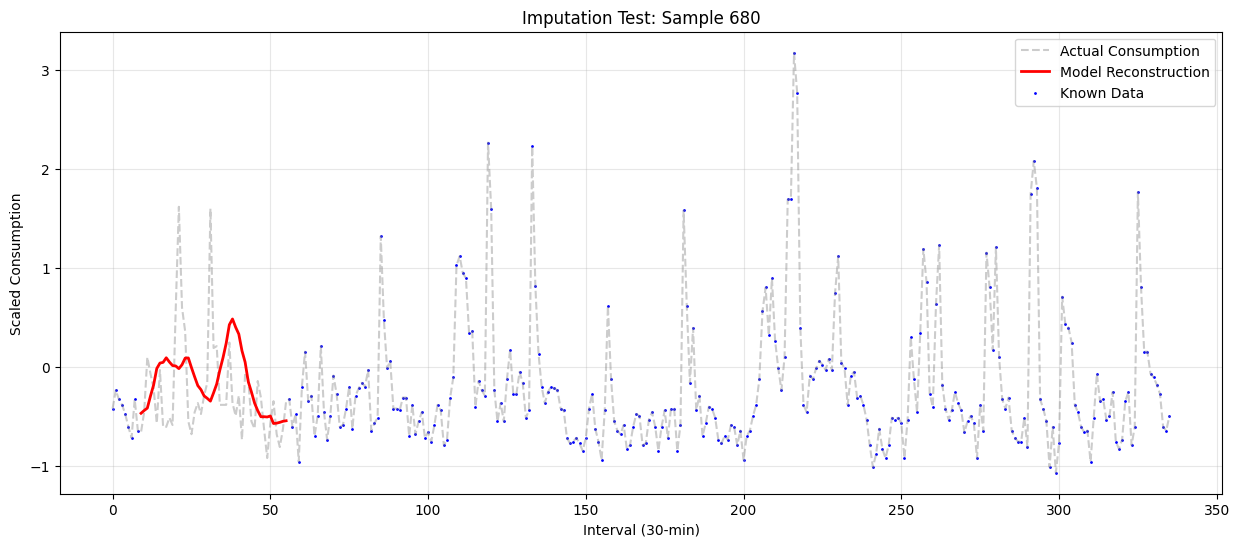

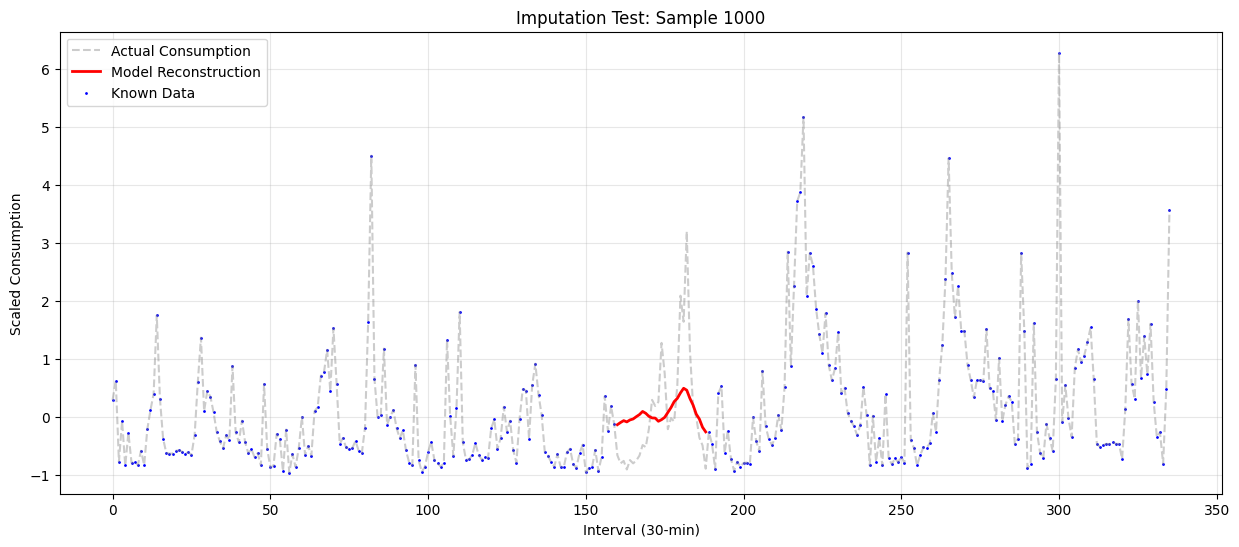

In [54]:
import matplotlib.pyplot as plt

def plot_reconstruction_test(model, dataset, device, sample_idx=500):
    model.eval()
    with torch.no_grad():
        x, y, mask = dataset[sample_idx]
        x_batch = x.unsqueeze(0).to(device)

        # Get prediction
        pred = model(x_batch).cpu().squeeze() # [336]
        y_true = y.squeeze() # [336]
        mask_bool = mask.squeeze().bool() # True where data is known, False where hole is

        plt.figure(figsize=(15, 6))

        # 1. Plot the ground truth (what it SHOULD look like)
        plt.plot(y_true, label='Actual Consumption', color='gray', alpha=0.4, linestyle='--')

        # 2. Plot the reconstruction ONLY in the hole
        # We use ~mask_bool to select the indices where the hole was
        hole_indices = torch.where(~mask_bool)[0]
        plt.plot(hole_indices, pred[hole_indices], label='Model Reconstruction', color='red', linewidth=2)

        # 3. Plot the known data around the hole
        known_indices = torch.where(mask_bool)[0]
        plt.scatter(known_indices, y_true[known_indices], s=1, color='blue', label='Known Data')

        plt.title(f"Imputation Test: Sample {sample_idx}")
        plt.xlabel("Interval (30-min)")
        plt.ylabel("Scaled Consumption")
        plt.legend()
        plt.grid(True, alpha=0.3)
        plt.show()

# Run it for a few different samples
dm.setup()
val_dataset = dm.val_dataset
plot_reconstruction_test(model_lstm_imputer, val_dataset, device, sample_idx=680)
plot_reconstruction_test(model_lstm_imputer, val_dataset, device, sample_idx=1000)

In [ ]:
def plot_real_reconstruction(model, meter_id, df_holed, df_ground_truth, grid_df, scaler, device):
    """
    Plots model reconstruction vs ground truth for a real NaN hole in a holed meter.

    All DataFrame arguments must be pre-sliced to the desired window before calling.

    Args:
        model: The trained model (will be set to eval mode)
        meter_id: The specific column name (e.g., 'holed_123')
        df_holed: Pre-sliced DataFrame with NaN holes (window_size rows)
        df_ground_truth: Pre-sliced ground truth DataFrame (window_size rows)
        grid_df: Pre-sliced enriched grid pulse, already scaled (window_size rows)
        scaler: A single-column StandardScaler with the correct mean/std from training
        device: torch device
    """
    model.eval()

    raw_segment = df_holed[meter_id].values.reshape(-1, 1)
    mask = (~np.isnan(raw_segment)).astype('float32')
    scaled_segment = scaler.transform(np.nan_to_num(raw_segment))

    grid_segment = grid_df.values
    x_input = np.column_stack([scaled_segment, mask, grid_segment])
    x_tensor = torch.tensor(x_input).unsqueeze(0).to(device).float()

    with torch.no_grad():
        pred_scaled = model(x_tensor).cpu().squeeze().numpy().reshape(-1, 1)
        pred_watts = scaler.inverse_transform(pred_scaled).flatten()
        true_watts = df_ground_truth[meter_id].values

    plt.figure(figsize=(15, 6))

    print(true_watts.shape)
    plt.plot(true_watts, label='Ground Truth (CSV)', color='gray', alpha=0.4, linestyle='--')

    mask_flat = mask.flatten()
    hole_idx = np.where(mask_flat == 0)[0]
    plt.plot(hole_idx, pred_watts[hole_idx], label='Model Reconstruction (Watts)', color='red', linewidth=2)

    known_idx = np.where(mask_flat == 1)[0]
    plt.scatter(known_idx, true_watts[known_idx], s=1, color='blue', label='Known Data')

    plt.title(f"Real Reconstruction for {meter_id}")
    plt.ylabel("Power (Watts)")
    plt.legend()
    plt.show()

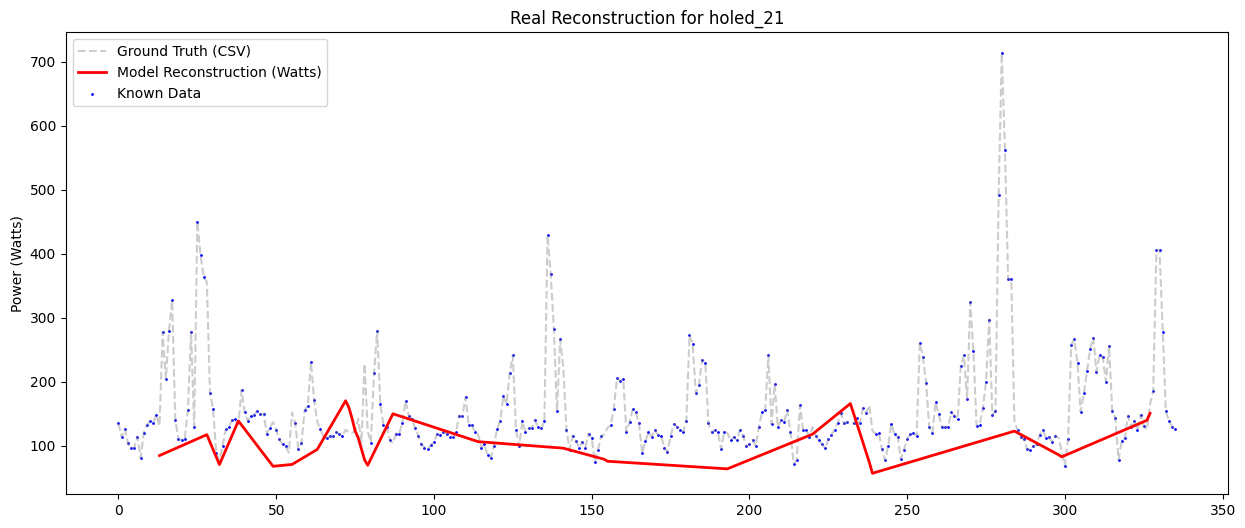

In [60]:
test_meter_id = df_train_holed.columns[20]

first_nan_idx = df_train_holed[test_meter_id].isna().idxmax()
start_pos = max(0, df_train_holed.index.get_loc(first_nan_idx) - 168)
end_pos = start_pos + 336

# USE THE TRAINING SCALER — not a new one!
col_idx = list(df_train_holed.columns).index(test_meter_id)
test_scaler = StandardScaler()
test_scaler.mean_ = np.array([scaler_holed.mean_[col_idx]])
test_scaler.scale_ = np.array([scaler_holed.scale_[col_idx]])
test_scaler.var_ = np.array([scaler_holed.var_[col_idx]])
test_scaler.n_features_in_ = 1

plot_real_reconstruction(
    model=model_lstm_imputer,
    meter_id=test_meter_id,
    df_holed=df_train_holed.iloc[start_pos:end_pos],
    df_ground_truth=y_train_data.iloc[start_pos:end_pos],
    grid_df=grid_pulse_enriched.iloc[start_pos:end_pos],
    scaler=test_scaler,
    device=device
)